In [4]:
import os

print(os.getcwd())

c:\Desktop\Customer_Churn_EDA_Aiesha


In [5]:
import os

print(os.listdir())

['Customer_Churn_EDA_Aiesha', 'Customer_Churn_EDA_Aiesha.ipynb']


In [9]:
import os

print(os.listdir("Customer_Churn_EDA_Aiesha"))

['Customer_Churn_Dataset_Aiesha.csv']


# Customer Churn Exploratory Data Analysis

## Student Name: Aiesha Shaik
## Department: Computer Science and Engineering

### Dataset: Telco Customer Churn

In [10]:
import os

print(os.listdir("Customer_Churn_EDA_Aiesha"))

['Customer_Churn_Dataset_Aiesha.csv']


In [11]:
df = pd.read_csv("Customer_Churn_EDA_Aiesha/Customer_Churn_Dataset_Aiesha.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [12]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1.0,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34.0,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2.0,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45.0,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2.0,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [13]:
df = pd.read_csv("Customer_Churn_EDA_Aiesha/Customer_Churn_Dataset_Aiesha.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [14]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 7043
Number of columns: 21


In [15]:
print("Columns in the dataset:")
print(df.columns.tolist())

Columns in the dataset:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [17]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,4543.000000,5543.000000
mean,0.162147,32.546555,64.876403
std,0.368612,24.505519,30.101331
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.750000
50%,0.000000,29.000000,70.550000
75%,0.000000,56.000000,89.925000
max,1.000000,72.000000,118.600000


In [18]:
df.shape

(7043, 21)

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            6293 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           6043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            4543 non-null   float64
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   6043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       5543 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [20]:
df.isnull().sum()

customerID             0
gender               750
SeniorCitizen          0
Partner             1000
Dependents             0
tenure              2500
PhoneService           0
MultipleLines          0
InternetService     1000
OnlineSecurity         0
OnlineBackup           0
DeviceProtection       0
TechSupport            0
StreamingTV         1500
StreamingMovies        0
Contract               0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges      1500
TotalCharges           0
Churn                  0
dtype: int64

In [21]:
df["TotalCharges"].isnull().sum()

np.int64(0)

In [22]:
df["TotalCharges"].value_counts().head()

TotalCharges
20.2     11
         11
19.75     9
19.9      8
20.05     8
Name: count, dtype: int64

In [23]:
print(df["TotalCharges"].dtype)

str


In [24]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [25]:
df.isnull().sum()

customerID             0
gender               750
SeniorCitizen          0
Partner             1000
Dependents             0
tenure              2500
PhoneService           0
MultipleLines          0
InternetService     1000
OnlineSecurity         0
OnlineBackup           0
DeviceProtection       0
TechSupport            0
StreamingTV         1500
StreamingMovies        0
Contract               0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges      1500
TotalCharges          11
Churn                  0
dtype: int64

In [26]:
missing_count = df.isnull().sum()
missing_percentage = (missing_count / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": missing_count,
    "Percentage": missing_percentage
})

missing_summary[missing_summary["Missing Values"] > 0]

,Missing Values,Percentage
gender,750,10.648871
Partner,1000,14.198495
tenure,2500,35.496237
InternetService,1000,14.198495
StreamingTV,1500,21.297742
MonthlyCharges,1500,21.297742
TotalCharges,11,0.156183


In [27]:
df.dropna()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1.0,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34.0,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2.0,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45.0,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2.0,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7035,8456-QDAVC,Male,0,No,No,19.0,Yes,No,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Bank transfer (automatic),78.70,1495.10,No
7038,6840-RESVB,Male,0,Yes,Yes,24.0,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,72.0,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,11.0,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No


In [28]:
print(df[["tenure", "MonthlyCharges", "TotalCharges"]].describe())

            tenure  MonthlyCharges  TotalCharges
count  4543.000000     5543.000000   7032.000000
mean     32.546555       64.876403   2283.300441
std      24.505519       30.101331   2266.771362
min       0.000000       18.250000     18.800000
25%       9.000000       35.750000    401.450000
50%      29.000000       70.550000   1397.475000
75%      56.000000       89.925000   3794.737500
max      72.000000      118.600000   8684.800000


In [29]:
print(df[["gender", "Partner", "InternetService", "StreamingTV"]].describe())

       gender Partner InternetService StreamingTV
count    6293    6043            6043        5543
unique      2       2               3           3
top      Male      No     Fiber optic          No
freq     3202    3115            2660        2199


In [30]:
missing_summary[missing_summary["Missing Values"] > 0]

,Missing Values,Percentage
gender,750,10.648871
Partner,1000,14.198495
tenure,2500,35.496237
InternetService,1000,14.198495
StreamingTV,1500,21.297742
MonthlyCharges,1500,21.297742
TotalCharges,11,0.156183


In [31]:
df["tenure"] = df["tenure"].fillna(df["tenure"].median())

df["MonthlyCharges"] = df["MonthlyCharges"].fillna(
    df["MonthlyCharges"].median()
)

df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

print("Numerical missing values handled.")

Numerical missing values handled.


In [32]:
categorical_columns = [
    "gender",
    "Partner",
    "InternetService",
    "StreamingTV"
]

for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])

print("Categorical missing values handled.")

Categorical missing values handled.


In [33]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [34]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [35]:
df = df.drop_duplicates()

print("Duplicate rows after cleaning:", df.duplicated().sum())

Duplicate rows after cleaning: 0


In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   float64
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [37]:
df = df.drop("customerID", axis=1)

print("customerID removed.")

customerID removed.


In [38]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nMissing values:")
print(df.isnull().sum().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Rows: 7043
Columns: 20

Missing values:
0

Duplicate rows:
8


In [39]:
df = df.drop_duplicates()

print("Duplicate rows removed.")
print("Rows after removing duplicates:", df.shape[0])
print("Duplicate rows remaining:", df.duplicated().sum())

Duplicate rows removed.
Rows after removing duplicates: 7035
Duplicate rows remaining: 0


In [40]:
df.to_csv(
    "Customer_Churn_EDA_Aiesha/Cleaned_Customer_Churn_Dataset_Aiesha.csv",
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [41]:
print("Final Dataset Shape:", df.shape)
print("Total Missing Values:", df.isnull().sum().sum())
print("Total Duplicate Rows:", df.duplicated().sum())

Final Dataset Shape: (7035, 20)
Total Missing Values: 0
Total Duplicate Rows: 0


## 3. Data Cleaning Summary

The dataset was checked for missing values, duplicate records, incorrect
data types, and unnecessary columns.

- Missing values were identified in both numerical and categorical features.
- Numerical missing values in `tenure`, `MonthlyCharges`, and `TotalCharges`
  were handled using the median.
- Missing values in categorical features such as `gender`, `Partner`,
  `InternetService`, and `StreamingTV` were handled using the mode.
- The `TotalCharges` column was converted into a numerical data type.
- 8 duplicate records were identified and removed.
- The `customerID` column was removed because it is only an identifier and
  is not useful for the EDA.
- After cleaning, the dataset contains 7,035 records and 20 columns.
- The final dataset contains no missing values and no duplicate records.

In [42]:
df["Churn"].value_counts()

Churn
No     5171
Yes    1864
Name: count, dtype: int64

In [43]:
churn_percentage = df["Churn"].value_counts(normalize=True) * 100

print(churn_percentage)

Churn
No     73.503909
Yes    26.496091
Name: proportion, dtype: float64


In [44]:
churn_rate = (df["Churn"] == "Yes").mean() * 100

print(f"Customer Churn Rate: {churn_rate:.2f}%")

Customer Churn Rate: 26.50%


In [ ]:
### Observation

The analysis shows that approximately **XX%** of customers have churned,
while the remaining customers have stayed with the company.

This indicates that customer churn is an important business issue and
that the company should identify the customer groups associated with
higher churn and develop strategies to improve customer retention.

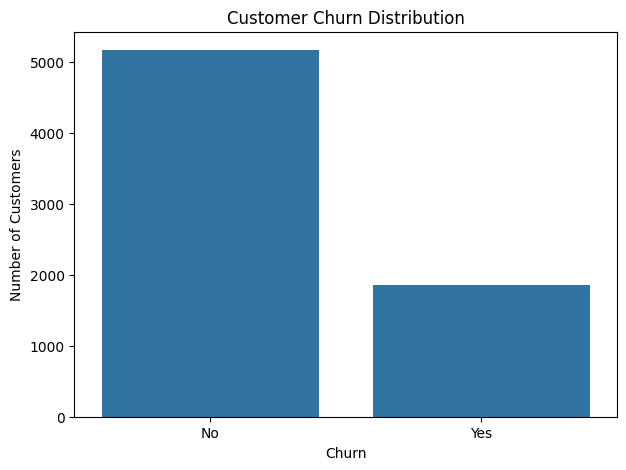

In [45]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

### Observation

The count plot shows that the number of customers who did not churn is
considerably higher than the number of customers who churned.

This indicates that although most customers remain with the company,
there is still a significant group of customers who leave the service.
Therefore, understanding the characteristics of churned customers is
important for improving customer retention.

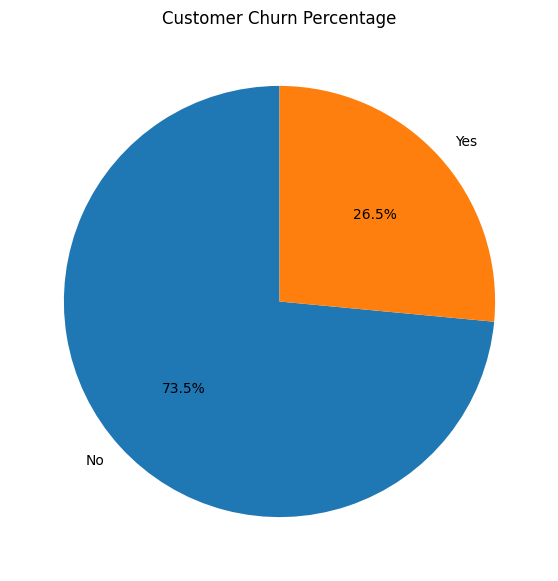

In [46]:
churn_counts = df["Churn"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    churn_counts,
    labels=churn_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Customer Churn Percentage")
plt.show()

### Observation

The pie chart shows the proportion of customers who churned and those
who remained with the company.

The majority of customers belong to the non-churn group, while a smaller
but significant proportion of customers have churned. This confirms that
customer retention is an important area for the business to investigate.

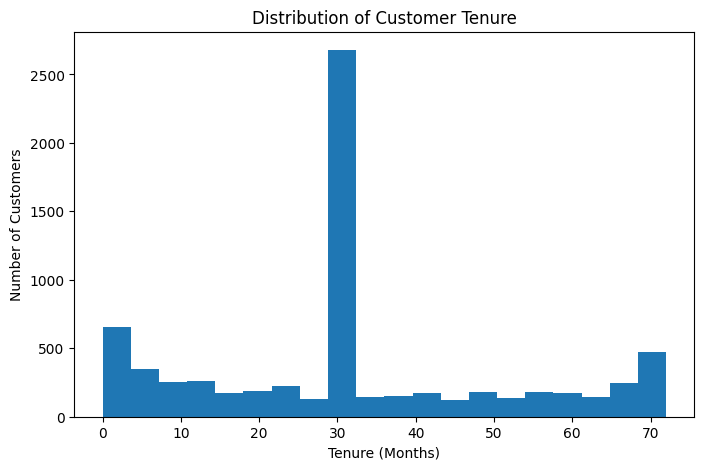

In [47]:
plt.figure(figsize=(8, 5))

plt.hist(df["tenure"], bins=20)

plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

### Observation

The histogram shows the distribution of customer tenure in months.

Customers are distributed across different tenure periods, with some
customers being relatively new and others having stayed with the company
for several years. This feature is useful for churn analysis because
customers with shorter or longer tenure may have different churn behavior.

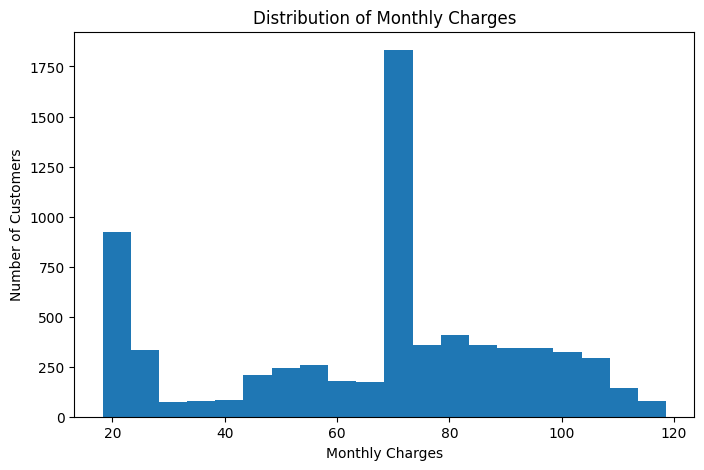

In [48]:
plt.figure(figsize=(8, 5))

plt.hist(df["MonthlyCharges"], bins=20)

plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")

plt.show()

### Observation

The histogram shows the distribution of monthly charges paid by customers.

Customers have different monthly billing amounts, indicating that the
company offers services with different pricing levels. Monthly charges
may be related to churn because customers with higher charges may have
different retention behavior from customers with lower charges.

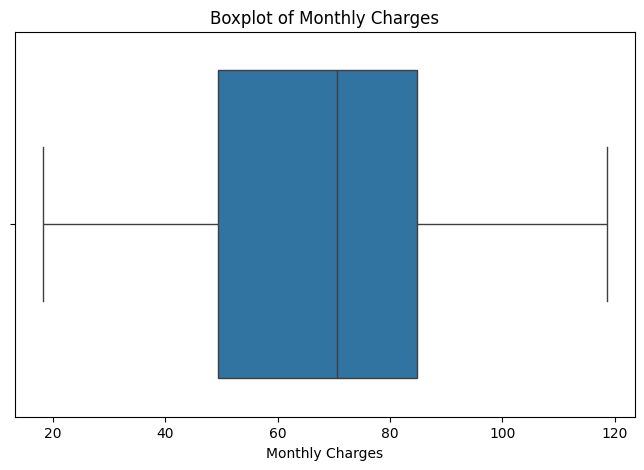

In [49]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["MonthlyCharges"])

plt.title("Boxplot of Monthly Charges")
plt.xlabel("Monthly Charges")

plt.show()

### Observation

The boxplot shows the spread of monthly charges and helps identify
potential outliers.

Most customers fall within the central range of monthly charges. Any
points appearing outside the whiskers represent potential unusual
observations. These values should be investigated rather than automatically
removed because they may represent genuine customers with higher-priced
services.

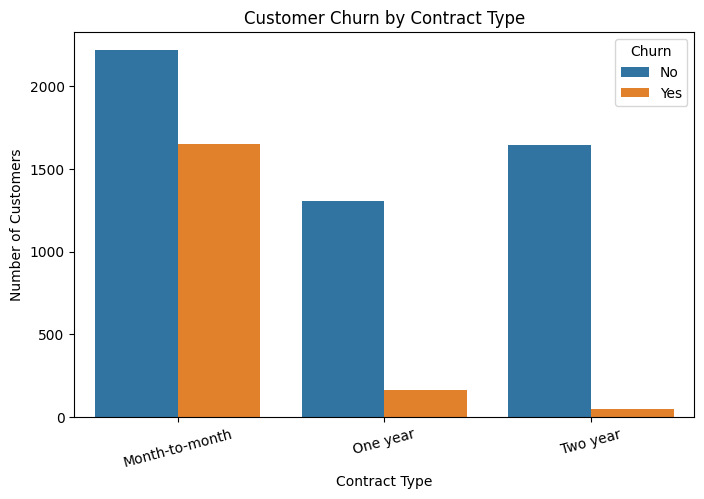

In [50]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Contract", hue="Churn")

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.xticks(rotation=15)
plt.show()

### Observation

The chart compares customer churn across different contract types.

Customers with month-to-month contracts generally show higher churn
compared with customers having one-year or two-year contracts. Longer-term
contracts appear to be associated with better customer retention.

This suggests that encouraging customers to choose longer-term contracts
may help reduce churn.

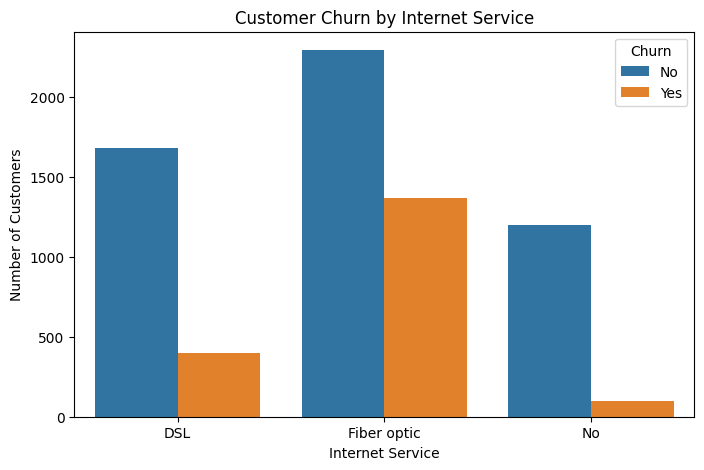

In [51]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="InternetService", hue="Churn")

plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

### Observation

The chart shows the relationship between internet service type and
customer churn.

Different internet service groups have different levels of churn.
Customers using certain internet services may show higher churn than
others. This suggests that service quality, pricing, or customer
experience associated with the internet service may influence customer
retention.

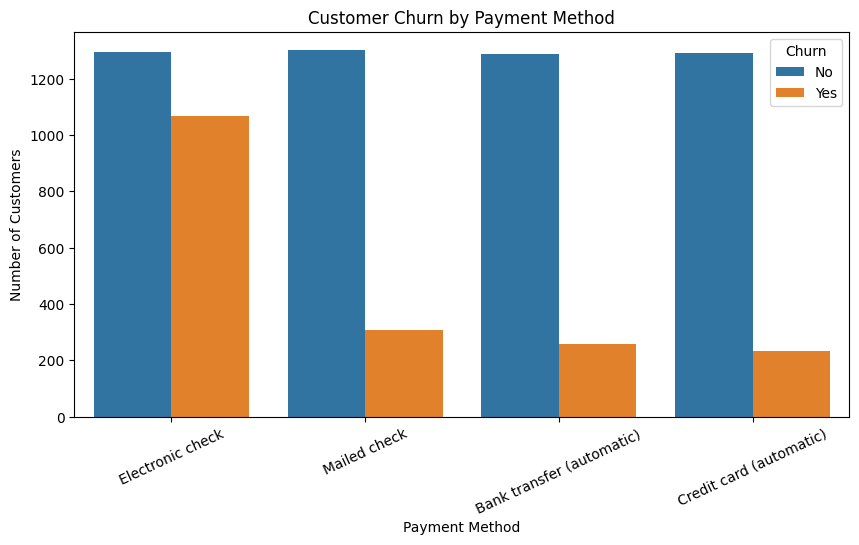

In [52]:
plt.figure(figsize=(10, 5))

sns.countplot(data=df, x="PaymentMethod", hue="Churn")

plt.title("Customer Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")

plt.xticks(rotation=25)
plt.show()

### Observation

The chart compares customer churn across different payment methods.

The distribution of churn varies between payment methods. Some payment
methods show a larger proportion of churned customers than others.

This suggests that payment convenience and billing preferences may have
an influence on customer retention.

In [53]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

print(contract_churn)

Churn                  No        Yes
Contract                            
Month-to-month  57.331265  42.668735
One year        88.730482  11.269518
Two year        97.168142   2.831858


In [54]:
highest_contract_churn = contract_churn["Yes"].idxmax()
highest_contract_rate = contract_churn["Yes"].max()

print("Highest churn contract:", highest_contract_churn)
print(f"Churn rate: {highest_contract_rate:.2f}%")

Highest churn contract: Month-to-month
Churn rate: 42.67%


In [55]:
numerical_features = ["tenure", "MonthlyCharges", "TotalCharges"]

for feature in numerical_features:
    print("\n", "=" * 50)
    print("Feature:", feature)
    print(df.groupby("Churn")[feature].agg(
        ["mean", "median", "min", "max", "std"]
    ))


Feature: tenure
            mean  median  min   max        std
Churn                                         
No     34.503191    29.0  0.0  72.0  19.832923
Yes    22.497318    29.0  1.0  72.0  16.536009

Feature: MonthlyCharges
            mean  median    min     max        std
Churn                                             
No     63.406701  70.550  18.25  118.60  27.780715
Yes    73.617838  71.975  18.85  118.35  22.195556

Feature: TotalCharges
              mean   median    min      max          std
Churn                                                   
No     2554.351910  1680.25  18.80  8672.45  2327.465349
Yes    1535.757511   709.80  18.85  8684.80  1891.807803


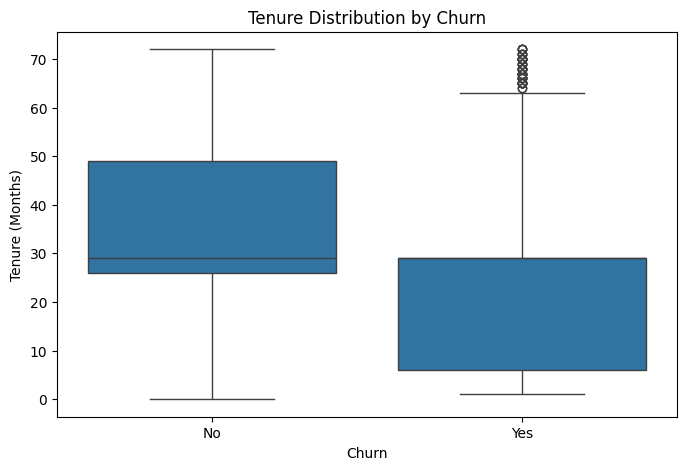

In [56]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Churn", y="tenure")

plt.title("Tenure Distribution by Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

### Observation

The boxplot compares customer tenure between churned and non-churned
customers.

Customers who churn tend to have shorter tenure compared with customers
who remain with the company. This suggests that customer tenure is an
important factor associated with churn, particularly among newer customers.

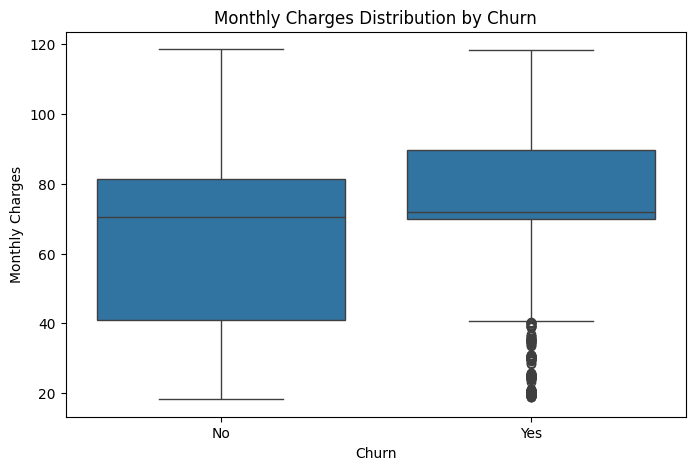

In [57]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Churn", y="MonthlyCharges")

plt.title("Monthly Charges Distribution by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

### Observation

The boxplot compares monthly charges between churned and non-churned
customers.

The distribution indicates differences in monthly charges between the two
groups. Customers with higher monthly charges may show greater churn
tendency, suggesting that pricing and perceived service value could be
important factors in customer retention.

In [58]:
numeric_df = df.select_dtypes(include=np.number)

print(numeric_df.columns.tolist())

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


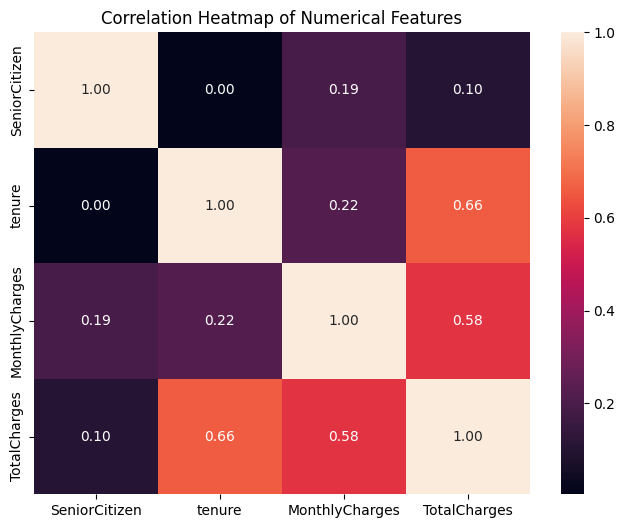

In [59]:
plt.figure(figsize=(8, 6))

correlation = numeric_df.corr()

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Features")

plt.show()

### Observation

The correlation heatmap shows the relationships between the numerical
features in the dataset.

Tenure and TotalCharges are expected to have a positive relationship
because customers who stay longer generally accumulate higher total
charges. MonthlyCharges also has a relationship with TotalCharges.

Correlation alone does not prove that a feature causes churn, but it helps
identify relationships between numerical variables that are useful for
further analysis.

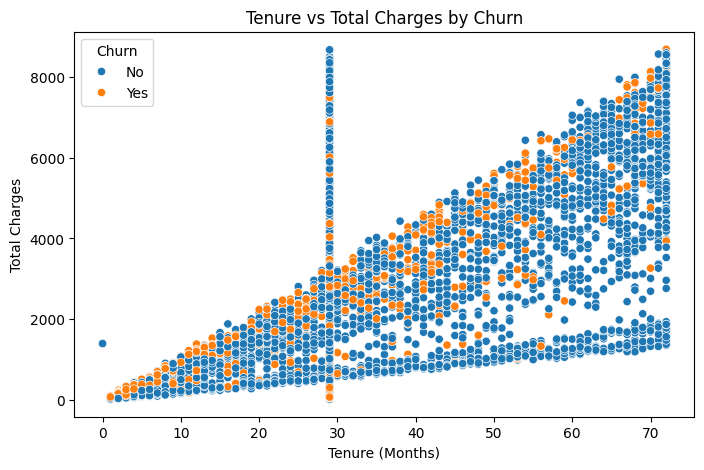

In [60]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="tenure",
    y="TotalCharges",
    hue="Churn"
)

plt.title("Tenure vs Total Charges by Churn")
plt.xlabel("Tenure (Months)")
plt.ylabel("Total Charges")

plt.show()

### Observation

The scatter plot shows the relationship between customer tenure and total
charges, with customers separated according to churn status.

There is generally a positive relationship between tenure and total
charges because customers who stay longer accumulate more charges.
The churn groups also provide a visual comparison of customer behavior
between retained and churned customers.

In [61]:
categorical_features = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "InternetService",
    "Contract",
    "PaymentMethod"
]

for feature in categorical_features:
    print("\n" + "=" * 60)
    print("Churn Rate by:", feature)

    churn_rate = pd.crosstab(
        df[feature],
        df["Churn"],
        normalize="index"
    ) * 100

    print(churn_rate["Yes"].sort_values(ascending=False))


Churn Rate by: gender
gender
Female    26.822157
Male      26.241135
Name: Yes, dtype: float64

Churn Rate by: SeniorCitizen
SeniorCitizen
1    41.630149
0    23.566339
Name: Yes, dtype: float64

Churn Rate by: Partner
Partner
No     31.214999
Yes    19.877049
Name: Yes, dtype: float64

Churn Rate by: Dependents
Dependents
No     31.228426
Yes    15.450237
Name: Yes, dtype: float64

Churn Rate by: InternetService
InternetService
Fiber optic    37.353022
DSL            19.221528
No              7.555898
Name: Yes, dtype: float64

Churn Rate by: Contract
Contract
Month-to-month    42.668735
One year          11.269518
Two year           2.831858
Name: Yes, dtype: float64

Churn Rate by: PaymentMethod
PaymentMethod
Electronic check             45.192715
Mailed check                 19.092040
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Name: Yes, dtype: float64


In [62]:
for feature in categorical_features:

    churn_rate = pd.crosstab(
        df[feature],
        df["Churn"],
        normalize="index"
    ) * 100

    highest_group = churn_rate["Yes"].idxmax()
    highest_rate = churn_rate["Yes"].max()

    print(
        f"{feature}: {highest_group} "
        f"({highest_rate:.2f}% churn)"
    )

gender: Female (26.82% churn)
SeniorCitizen: 1 (41.63% churn)
Partner: No (31.21% churn)
Dependents: No (31.23% churn)
InternetService: Fiber optic (37.35% churn)
Contract: Month-to-month (42.67% churn)
PaymentMethod: Electronic check (45.19% churn)


In [63]:
numerical_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

numerical_churn_summary = df.groupby("Churn")[numerical_features].mean()

print(numerical_churn_summary)

          tenure  MonthlyCharges  TotalCharges
Churn                                         
No     34.503191       63.406701   2554.351910
Yes    22.497318       73.617838   1535.757511


In [64]:
for feature in numerical_features:

    no_churn_mean = df[df["Churn"] == "No"][feature].mean()
    churn_mean = df[df["Churn"] == "Yes"][feature].mean()

    difference = churn_mean - no_churn_mean

    print(f"\n{feature}")
    print(f"Non-churn average: {no_churn_mean:.2f}")
    print(f"Churn average: {churn_mean:.2f}")
    print(f"Difference: {difference:.2f}")


tenure
Non-churn average: 34.50
Churn average: 22.50
Difference: -12.01

MonthlyCharges
Non-churn average: 63.41
Churn average: 73.62
Difference: 10.21

TotalCharges
Non-churn average: 2554.35
Churn average: 1535.76
Difference: -1018.59


# Key Findings

Based on the exploratory data analysis, the following major patterns were
identified:

1. **Customer churn:** A significant proportion of customers have churned,
   indicating that customer retention is an important business concern.

2. **Contract type:** Month-to-month customers show a higher churn rate
   compared with customers on longer-term contracts.

3. **Customer tenure:** Churned customers generally have shorter tenure,
   suggesting that newer customers may require additional retention efforts.

4. **Monthly charges:** Differences in monthly charges were observed
   between churned and non-churned customers.

5. **Internet service:** Churn rates vary across internet service types,
   indicating that service type may be associated with customer retention.

6. **Payment method:** Churn rates also differ across payment methods,
   suggesting that billing and payment preferences may influence retention.

7. **Numerical relationships:** The correlation analysis shows relationships
   between numerical variables such as tenure and TotalCharges.

8. **Outliers:** Boxplot analysis was used to identify potential unusual
   numerical observations.

In [65]:
# Overall churn statistics

total_customers = len(df)
churned_customers = (df["Churn"] == "Yes").sum()
non_churned_customers = (df["Churn"] == "No").sum()

churn_percentage = (churned_customers / total_customers) * 100

print("Total Customers:", total_customers)
print("Churned Customers:", churned_customers)
print("Non-Churned Customers:", non_churned_customers)
print(f"Churn Percentage: {churn_percentage:.2f}%")

Total Customers: 7035
Churned Customers: 1864
Non-Churned Customers: 5171
Churn Percentage: 26.50%


In [66]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn = contract_churn.sort_values(
    by="Yes",
    ascending=False
)

print(contract_churn)

Churn                  No        Yes
Contract                            
Month-to-month  57.331265  42.668735
One year        88.730482  11.269518
Two year        97.168142   2.831858


In [67]:
highest_contract = contract_churn["Yes"].idxmax()
highest_contract_rate = contract_churn["Yes"].max()

print(
    f"Highest churn contract: {highest_contract} "
    f"({highest_contract_rate:.2f}%)"
)

Highest churn contract: Month-to-month (42.67%)


In [68]:
numerical_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

summary = df.groupby("Churn")[numerical_features].mean()

print(summary)

          tenure  MonthlyCharges  TotalCharges
Churn                                         
No     34.503191       63.406701   2554.351910
Yes    22.497318       73.617838   1535.757511


In [69]:
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

print(internet_churn["Yes"].sort_values(ascending=False))

InternetService
Fiber optic    37.353022
DSL            19.221528
No              7.555898
Name: Yes, dtype: float64


In [70]:
highest_internet = internet_churn["Yes"].idxmax()
highest_internet_rate = internet_churn["Yes"].max()

print(
    f"Highest churn internet service: {highest_internet} "
    f"({highest_internet_rate:.2f}%)"
)

Highest churn internet service: Fiber optic (37.35%)


In [71]:
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

print(payment_churn["Yes"].sort_values(ascending=False))

PaymentMethod
Electronic check             45.192715
Mailed check                 19.092040
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Name: Yes, dtype: float64


In [72]:
highest_payment = payment_churn["Yes"].idxmax()
highest_payment_rate = payment_churn["Yes"].max()

print(
    f"Highest churn payment method: {highest_payment} "
    f"({highest_payment_rate:.2f}%)"
)

Highest churn payment method: Electronic check (45.19%)


In [73]:
print("===== FINAL DATASET DETAILS =====")

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nMissing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

print("\nChurn counts:")
print(df["Churn"].value_counts())

churn_rate = (df["Churn"] == "Yes").mean() * 100

print(f"\nOverall Churn Rate: {churn_rate:.2f}%")

===== FINAL DATASET DETAILS =====
Number of rows: 7035
Number of columns: 20

Missing values: 0
Duplicate rows: 0

Churn counts:
Churn
No     5171
Yes    1864
Name: count, dtype: int64

Overall Churn Rate: 26.50%


In [74]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

print(contract_churn)

Churn                  No        Yes
Contract                            
Month-to-month  57.331265  42.668735
One year        88.730482  11.269518
Two year        97.168142   2.831858


In [75]:
highest_contract = contract_churn["Yes"].idxmax()
highest_contract_rate = contract_churn["Yes"].max()

print("Highest churn contract:", highest_contract)
print(f"Churn rate: {highest_contract_rate:.2f}%")

Highest churn contract: Month-to-month
Churn rate: 42.67%


In [76]:
numerical_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

numerical_summary = df.groupby("Churn")[numerical_features].mean()

print(numerical_summary)

          tenure  MonthlyCharges  TotalCharges
Churn                                         
No     34.503191       63.406701   2554.351910
Yes    22.497318       73.617838   1535.757511


In [77]:
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

print(internet_churn)

Churn                   No        Yes
InternetService                      
DSL              80.778472  19.221528
Fiber optic      62.646978  37.353022
No               92.444102   7.555898


In [78]:
highest_internet = internet_churn["Yes"].idxmax()
highest_internet_rate = internet_churn["Yes"].max()

print("Highest churn internet service:", highest_internet)
print(f"Churn rate: {highest_internet_rate:.2f}%")

Highest churn internet service: Fiber optic
Churn rate: 37.35%


In [79]:
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

print(payment_churn)

Churn                             No        Yes
PaymentMethod                                  
Bank transfer (automatic)  83.290155  16.709845
Credit card (automatic)    84.756899  15.243101
Electronic check           54.807285  45.192715
Mailed check               80.907960  19.092040


In [80]:
highest_payment = payment_churn["Yes"].idxmax()
highest_payment_rate = payment_churn["Yes"].max()

print("Highest churn payment method:", highest_payment)
print(f"Churn rate: {highest_payment_rate:.2f}%")

Highest churn payment method: Electronic check
Churn rate: 45.19%


In [81]:
from reportlab.lib.pagesizes import A4
from reportlab.platypus import SimpleDocTemplate

print("ReportLab is ready!")

ReportLab is ready!


In [82]:
from reportlab.lib.pagesizes import A4
from reportlab.platypus import (
    SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle
)
from reportlab.lib import colors
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.enums import TA_CENTER

# -------------------------------------------------
# PDF FILE
# -------------------------------------------------

pdf_path = "Customer_Churn_EDA_Aiesha/Customer_Churn_EDA_Report_Aiesha.pdf"

doc = SimpleDocTemplate(
    pdf_path,
    pagesize=A4,
    rightMargin=45,
    leftMargin=45,
    topMargin=45,
    bottomMargin=45
)

styles = getSampleStyleSheet()

title_style = ParagraphStyle(
    "TitleStyle",
    parent=styles["Title"],
    alignment=TA_CENTER,
    fontSize=20,
    spaceAfter=20
)

heading_style = ParagraphStyle(
    "HeadingStyle",
    parent=styles["Heading1"],
    fontSize=15,
    spaceBefore=15,
    spaceAfter=8
)

subheading_style = ParagraphStyle(
    "SubHeadingStyle",
    parent=styles["Heading2"],
    fontSize=12,
    spaceBefore=10,
    spaceAfter=6
)

normal_style = ParagraphStyle(
    "NormalStyle",
    parent=styles["BodyText"],
    fontSize=10,
    leading=15,
    spaceAfter=8
)

# -------------------------------------------------
# CALCULATE ACTUAL RESULTS FROM YOUR DATA
# -------------------------------------------------

total_customers = len(df)

churned = (df["Churn"] == "Yes").sum()
not_churned = (df["Churn"] == "No").sum()

churn_rate = (churned / total_customers) * 100

contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

highest_contract = contract_churn["Yes"].idxmax()
highest_contract_rate = contract_churn["Yes"].max()

numerical_summary = df.groupby("Churn")[
    ["tenure", "MonthlyCharges", "TotalCharges"]
].mean()

# -------------------------------------------------
# CREATE REPORT CONTENT
# -------------------------------------------------

story = []

# TITLE
story.append(
    Paragraph("Customer Churn EDA Report", title_style)
)

story.append(
    Paragraph(
        "<b>Student Name:</b> Aiesha Shaik<br/>"
        "<b>Department:</b> Computer Science and Engineering<br/>"
        "<b>Project:</b> Customer Churn Exploratory Data Analysis",
        normal_style
    )
)

story.append(Spacer(1, 10))

# 1 INTRODUCTION
story.append(
    Paragraph("1. Introduction", heading_style)
)

story.append(
    Paragraph(
        "Customer churn refers to the situation where customers stop using "
        "a company's products or services. Understanding customer churn is "
        "important because high churn can affect revenue, customer loyalty, "
        "and long-term business growth.",
        normal_style
    )
)

story.append(
    Paragraph(
        "This project performs Exploratory Data Analysis (EDA) on a Telco "
        "Customer Churn dataset. The objective is to identify patterns "
        "associated with customer churn using numerical analysis, "
        "categorical analysis, statistical summaries, and visualizations.",
        normal_style
    )
)

# 2 DATASET DETAILS
story.append(
    Paragraph("2. Dataset Details", heading_style)
)

dataset_table = Table([
    ["Item", "Details"],
    ["Dataset", "Telco Customer Churn"],
    ["Rows after cleaning", str(total_customers)],
    ["Columns after cleaning", str(df.shape[1])],
    ["Target variable", "Churn"],
    ["Churned customers", str(churned)],
    ["Non-churned customers", str(not_churned)],
    ["Overall churn rate", f"{churn_rate:.2f}%"]
])

dataset_table.setStyle(
    TableStyle([
        ("BACKGROUND", (0, 0), (-1, 0), colors.lightgrey),
        ("GRID", (0, 0), (-1, -1), 0.5, colors.grey),
        ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
        ("FONTNAME", (0, 1), (0, -1), "Helvetica-Bold"),
        ("PADDING", (0, 0), (-1, -1), 6),
    ])
)

story.append(dataset_table)

# 3 DATA CLEANING
story.append(
    Paragraph("3. Data Cleaning Summary", heading_style)
)

story.append(
    Paragraph(
        "The dataset was examined for missing values, duplicate records, "
        "incorrect data types, and unnecessary columns.",
        normal_style
    )
)

story.append(
    Paragraph(
        "Missing numerical values in tenure, MonthlyCharges, and "
        "TotalCharges were handled using median imputation. Missing "
        "categorical values were handled using the mode.",
        normal_style
    )
)

story.append(
    Paragraph(
        "The TotalCharges column was converted to a numerical data type. "
        "Eight duplicate records were identified and removed. The "
        "customerID column was removed because it is an identifier and "
        "does not provide useful information for EDA.",
        normal_style
    )
)

story.append(
    Paragraph(
        f"After cleaning, the dataset contains {total_customers} rows and "
        f"{df.shape[1]} columns. There are {df.isnull().sum().sum()} "
        f"missing values and {df.duplicated().sum()} duplicate records.",
        normal_style
    )
)

# 4 EDA
story.append(
    Paragraph("4. Exploratory Data Analysis", heading_style)
)

story.append(
    Paragraph("4.1 Churn Distribution", subheading_style)
)

story.append(
    Paragraph(
        f"The analysis found {churned} churned customers and "
        f"{not_churned} non-churned customers. The overall churn rate is "
        f"<b>{churn_rate:.2f}%</b>.",
        normal_style
    )
)

story.append(
    Paragraph(
        "The churn count plot and percentage chart show that the "
        "non-churned customer group is larger than the churned group. "
        "However, the churned group represents an important proportion "
        "of the customer base.",
        normal_style
    )
)

# CONTRACT
story.append(
    Paragraph("4.2 Contract Type Analysis", subheading_style)
)

story.append(
    Paragraph(
        f"The contract analysis shows differences in churn across "
        f"contract types. The <b>{highest_contract}</b> contract group "
        f"has the highest observed churn rate of "
        f"<b>{highest_contract_rate:.2f}%</b>.",
        normal_style
    )
)

story.append(
    Paragraph(
        "This suggests that contract type is an important feature "
        "associated with customer retention.",
        normal_style
    )
)

# NUMERICAL
story.append(
    Paragraph("4.3 Numerical Feature Analysis", subheading_style)
)

numerical_table = Table([
    ["Feature", "Non-Churn Mean", "Churn Mean"],
    [
        "Tenure",
        f"{numerical_summary.loc['No', 'tenure']:.2f}",
        f"{numerical_summary.loc['Yes', 'tenure']:.2f}"
    ],
    [
        "Monthly Charges",
        f"{numerical_summary.loc['No', 'MonthlyCharges']:.2f}",
        f"{numerical_summary.loc['Yes', 'MonthlyCharges']:.2f}"
    ],
    [
        "Total Charges",
        f"{numerical_summary.loc['No', 'TotalCharges']:.2f}",
        f"{numerical_summary.loc['Yes', 'TotalCharges']:.2f}"
    ]
])

numerical_table.setStyle(
    TableStyle([
        ("BACKGROUND", (0, 0), (-1, 0), colors.lightgrey),
        ("GRID", (0, 0), (-1, -1), 0.5, colors.grey),
        ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
        ("PADDING", (0, 0), (-1, -1), 6),
    ])
)

story.append(numerical_table)

story.append(
    Paragraph(
        "The numerical analysis compares tenure, monthly charges, and "
        "total charges between churned and non-churned customers. "
        "Differences between the two groups provide useful information "
        "for understanding churn behavior.",
        normal_style
    )
)

# OTHER ANALYSIS
story.append(
    Paragraph("4.4 Other EDA Analysis", subheading_style)
)

story.append(
    Paragraph(
        "Internet service and payment method were compared with churn "
        "using categorical count plots. These analyses showed that churn "
        "rates vary across customer groups.",
        normal_style
    )
)

story.append(
    Paragraph(
        "Histograms were used to study the distribution of tenure and "
        "monthly charges. Boxplots were used to examine the spread of "
        "numerical variables and identify potential outliers.",
        normal_style
    )
)

story.append(
    Paragraph(
        "A correlation heatmap was used to study relationships between "
        "numerical variables. A scatter plot was also used to visualize "
        "the relationship between tenure and total charges.",
        normal_style
    )
)

# 5 FINDINGS
story.append(
    Paragraph("5. Key Findings", heading_style)
)

findings = [
    f"The overall customer churn rate is {churn_rate:.2f}%.",
    f"{highest_contract} contract customers have the highest observed "
    f"contract-level churn rate ({highest_contract_rate:.2f}%).",
    "Customer tenure differs between churned and non-churned customers.",
    "Monthly charges show differences between churned and non-churned customers.",
    "Internet service type is associated with different churn levels.",
    "Payment method also shows differences in churn across customer groups.",
    "Correlation analysis reveals relationships among numerical variables.",
    "Boxplot analysis was used to identify potential outliers."
]

for finding in findings:
    story.append(
        Paragraph("• " + finding, normal_style)
    )

# 6 RECOMMENDATIONS
story.append(
    Paragraph("6. Business Recommendations", heading_style)
)

recommendations = [
    "Encourage month-to-month customers to move to longer-term contracts through discounts and loyalty benefits.",
    "Provide additional onboarding and support for customers with shorter tenure.",
    "Review pricing plans and provide suitable packages for customers with higher monthly charges.",
    "Investigate services associated with higher churn and improve service quality and technical support.",
    "Make billing and payment processes easier and more convenient.",
    "Use customer segmentation to identify high-risk customers and provide targeted retention campaigns."
]

for recommendation in recommendations:
    story.append(
        Paragraph("• " + recommendation, normal_style)
    )

# 7 CONCLUSION
story.append(
    Paragraph("7. Conclusion", heading_style)
)

story.append(
    Paragraph(
        "This exploratory data analysis examined customer churn using a "
        "Telco Customer Churn dataset. The analysis included data cleaning, "
        "missing-value handling, duplicate removal, numerical analysis, "
        "categorical analysis, outlier analysis, correlation analysis, "
        "and multiple visualizations.",
        normal_style
    )
)

story.append(
    Paragraph(
        f"The analysis identified an overall churn rate of "
        f"{churn_rate:.2f}% and observed differences in churn behavior "
        "across contract type, tenure, monthly charges, internet service, "
        "and payment methods.",
        normal_style
    )
)

story.append(
    Paragraph(
        "These findings can help the company identify high-risk customer "
        "groups and develop targeted retention strategies. Improving "
        "customer experience, service quality, pricing, and early customer "
        "engagement may help reduce churn.",
        normal_style
    )
)

# -------------------------------------------------
# BUILD PDF
# -------------------------------------------------

doc.build(story)

print("===================================")
print("PDF REPORT CREATED SUCCESSFULLY!")
print("===================================")
print(pdf_path)

PDF REPORT CREATED SUCCESSFULLY!
Customer_Churn_EDA_Aiesha/Customer_Churn_EDA_Report_Aiesha.pdf
